# Charging Load Profile Evaluation — Per-Model Comparison
**Location Group 3 · Real vs each synthetic model configuration**

Each synthetic file = one model (depth × attention-heads grid).  
Best models from distributional evaluation:
- **CTGAN**: `d2_h8`  (from `evaluation_CTGAN.ipynb`)
- **Diffusion**: `d3_h2`  (from `best_diffusion_cfg.json` — depth=3, nhead=2)

Load-profile reconstruction: $\;P_h = \frac{E_{session}}{t_{conn}} \times \Delta h_{overlap}\;$ [kW]

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from pathlib import Path
import re
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
})

BASE_DIR       = Path("")
LOCATION_GROUP = 3

# ── Best models from distributional evaluation ────────────────────────────────
BEST_CTGAN     = "d2_h8"   # evaluation_CTGAN.ipynb   → synthetic_year_3_d2_8h
BEST_DIFFUSION = "d3_h2"   # best_diffusion_cfg.json  → depth=3, nhead=2

C_REAL  = "#2166ac"
C_CTGAN = "#d6604d"
C_DIFF  = "#4dac26"
C_OTHER = "#cccccc"

## 1 · Load Data (Location Group 3)

In [2]:
def filter_sessions(df):
    ok = (
        (df["connection_time"] > 0) & (df["connection_time"] <= 120) &
        (df["energy_session"]  > 0) & (df["energy_session"]  <= 150)
    )
    return df[ok].copy()


def parse_ctgan_id(stem):
    """synthetic_year_3_d2_8h → d2_h8  |  _off → _h0"""
    m = re.search(r"_(d\d)_(\d+)h$", stem)
    if m:
        return f"{m.group(1)}_h{m.group(2)}"
    m = re.search(r"_(d\d)_off$", stem)
    if m:
        return f"{m.group(1)}_h0"
    return None   # skip (e.g. timestamped files)


def parse_diff_id(stem):
    """synthetic_location_3_d2_h4 → d2_h4  |  _hnone → _h0"""
    m = re.search(r"_(d\d)_h(\d+)$", stem)
    if m:
        return f"{m.group(1)}_h{m.group(2)}"
    m = re.search(r"_(d\d)_hnone$", stem)
    if m:
        return f"{m.group(1)}_h0"
    return None   # skip (e.g. synthetic_2025.csv)


# ── Real data — location_group == 3 ──────────────────────────────────────────
real_raw = pd.read_csv(BASE_DIR / "data" / "EV_Charging_Data_processed.csv")
real_raw = real_raw[real_raw["location_group"] == LOCATION_GROUP].copy()
real_raw = filter_sessions(real_raw)
real_raw["plugin_time"] = pd.to_datetime(real_raw["plugin_time"])
real_raw["date"]        = real_raw["plugin_time"].dt.date
print(f"Real      : {len(real_raw):>5,} sessions · {real_raw['date'].nunique()} days")

# ── CTGAN — one dict entry per model config ───────────────────────────────────
ctgan_models = {}
for f in sorted((BASE_DIR / "CTGAN" / "synthetic").glob("*.csv")):
    mid = parse_ctgan_id(f.stem)
    if mid is None:
        continue
    df = filter_sessions(pd.read_csv(f))
    df["date"] = pd.to_datetime(df["__date__"]).dt.date
    ctgan_models[mid] = df
print(f"CTGAN     : {len(ctgan_models)} models — {sorted(ctgan_models)}")

# ── Diffusion — one dict entry per model config ───────────────────────────────
diff_models = {}
for f in sorted((BASE_DIR / "diffusion" / "synthetic").glob("*.csv")):
    mid = parse_diff_id(f.stem)
    if mid is None:
        continue
    df = filter_sessions(pd.read_csv(f))
    df["date"] = pd.to_datetime(df["__date__"]).dt.date
    diff_models[mid] = df
print(f"Diffusion : {len(diff_models)} models — {sorted(diff_models)}")

Real      : 4,665 sessions · 500 days
CTGAN     : 16 models — ['d1_h0', 'd1_h2', 'd1_h4', 'd1_h8', 'd2_h0', 'd2_h2', 'd2_h4', 'd2_h8', 'd3_h0', 'd3_h2', 'd3_h4', 'd3_h8', 'd4_h0', 'd4_h2', 'd4_h4', 'd4_h8']
Diffusion : 16 models — ['d1_h0', 'd1_h2', 'd1_h4', 'd1_h8', 'd2_h0', 'd2_h2', 'd2_h4', 'd2_h8', 'd3_h0', 'd3_h2', 'd3_h4', 'd3_h8', 'd4_h0', 'd4_h2', 'd4_h4', 'd4_h8']


## 2 · Aggregate Load Profiles

For each session: $P_{avg} = E / t_{conn}$ [kW]. That power is spread across every integer-hour slot the session occupies (fractional overlap tracked precisely). Grids are **normalised per average session** so datasets with different volumes are directly comparable.

In [3]:
def sessions_to_hourly_load(df):
    """Expand each session into (date, hour, load_kw) records."""
    starts   = df["plugin_hour"].values.astype(float)
    durs     = np.clip(df["connection_time"].values.astype(float), 0.01, 24.0)
    energies = np.clip(df["energy_session"].values.astype(float),  0.0,  np.inf)
    dates    = df["date"].values
    powers   = energies / durs   # average kW during session

    records = []
    for i in range(len(df)):
        s, d, p, dt = starts[i], durs[i], powers[i], dates[i]
        end = s + d
        h   = int(s)
        while h < end:
            ov = min(h + 1, end) - max(h, s)
            if ov > 0:
                records.append((dt, h % 24, p * ov))
            h += 1

    load = pd.DataFrame(records, columns=["date", "hour", "load_kw"])
    return load.groupby(["date", "hour"])["load_kw"].sum().reset_index()


def make_grid(load_df):
    """(date × hour) pivot filled with zeros for missing hours."""
    return (load_df
            .pivot_table(index="date", columns="hour",
                         values="load_kw", aggfunc="sum", fill_value=0.0)
            .reindex(columns=range(24), fill_value=0.0))


def norm_grid(grid, n_sessions):
    """Normalise to kW per average daily session count."""
    return grid / (n_sessions / len(grid))


def hourly_cv(norm):
    mu = norm.mean(axis=0).values
    sd = norm.std(axis=0).values
    return sd / (mu + 1e-6)


# ── Compute real grid ─────────────────────────────────────────────────────────
print("Building real grid …")
grid_real = make_grid(sessions_to_hourly_load(real_raw))
norm_real = norm_grid(grid_real, len(real_raw))
hours     = np.arange(24)
mu_real   = norm_real.mean(axis=0).values
cv_real   = hourly_cv(norm_real)
peak_real = norm_real.max(axis=1).values

# ── Compute per-model grids ───────────────────────────────────────────────────
print("Building CTGAN grids …")
ctgan_norms = {mid: norm_grid(make_grid(sessions_to_hourly_load(df)), len(df))
               for mid, df in ctgan_models.items()}

print("Building Diffusion grids …")
diff_norms  = {mid: norm_grid(make_grid(sessions_to_hourly_load(df)), len(df))
               for mid, df in diff_models.items()}

print(f"Done — {len(ctgan_norms)} CTGAN + {len(diff_norms)} Diffusion grids.")

Building real grid …
Building CTGAN grids …
Building Diffusion grids …
Done — 16 CTGAN + 16 Diffusion grids.


## 3 · Per-Model Metrics & Heatmaps

Four metrics computed for each (depth × heads) configuration against real data:

| Metric | Definition |
|---|---|
| **Load-curve RMSE** | $\sqrt{\frac{1}{24}\sum_h(\bar{P}^{syn}_h - \bar{P}^{real}_h)^2}$ |
| **Peak KS stat** | Two-sample KS statistic on daily peak distributions |
| **CV error** | $\frac{1}{24}\sum_h |CV^{syn}_h - CV^{real}_h|$ |
| **Peak rel. error** | $|\bar{P}^{syn}_{peak} - \bar{P}^{real}_{peak}| / \bar{P}^{real}_{peak}$ |

Black box = best model from distributional evaluation (TVComplement / KSComplement scores).

In [4]:
def model_metrics(norm):
    mu_syn   = norm.mean(axis=0).values
    rmse     = np.sqrt(np.mean((mu_real - mu_syn) ** 2))
    ks, _    = stats.ks_2samp(peak_real, norm.max(axis=1).values)
    cv_err   = np.mean(np.abs(hourly_cv(norm) - cv_real))
    peak_err = abs(norm.max(axis=1).mean() - peak_real.mean()) / (peak_real.mean() + 1e-9)
    return dict(rmse=rmse, ks_peak=ks, cv_err=cv_err, peak_rel_err=peak_err)


def build_metrics_df(norms_dict):
    rows = []
    for mid, norm in norms_dict.items():
        m = re.match(r"d(\d+)_h(\d+)", mid)
        rows.append({
            "model_id": mid,
            "depth":    int(m.group(1)) if m else -1,
            "heads":    int(m.group(2)) if m else -1,
            **model_metrics(norm),
        })
    return pd.DataFrame(rows).set_index("model_id")


ctgan_metrics = build_metrics_df(ctgan_norms)
diff_metrics  = build_metrics_df(diff_norms)

print("── CTGAN (sorted by load-curve RMSE) ──")
print(ctgan_metrics.sort_values("rmse")[["depth","heads","rmse","ks_peak","cv_err","peak_rel_err"]].to_string())
print("\n── Diffusion (sorted by load-curve RMSE) ──")
print(diff_metrics.sort_values("rmse")[["depth","heads","rmse","ks_peak","cv_err","peak_rel_err"]].to_string())

── CTGAN (sorted by load-curve RMSE) ──
          depth  heads      rmse   ks_peak    cv_err  peak_rel_err
model_id                                                          
d2_h4         2      4  0.050366  0.168740  0.141789      0.108169
d3_h2         3      2  0.058230  0.127671  0.078555      0.084490
d2_h8         2      8  0.080721  0.101397  0.089681      0.011966
d3_h4         3      4  0.085294  0.134466  0.136095      0.084938
d4_h8         4      8  0.098977  0.255187  0.082994      0.201185
d3_h0         3      0  0.102544  0.120603  0.041612      0.042545
d3_h8         3      8  0.111986  0.261233  0.100807      0.251910
d1_h0         1      0  0.131055  0.108813  0.084058      0.013049
d1_h2         1      2  0.152274  0.190274  0.089239      0.091126
d4_h4         4      4  0.158560  0.130154  0.067823      0.155707
d2_h2         2      2  0.165683  0.144795  0.158131      0.175127
d1_h4         1      4  0.167130  0.130411  0.106768      0.047173
d1_h8         1      8

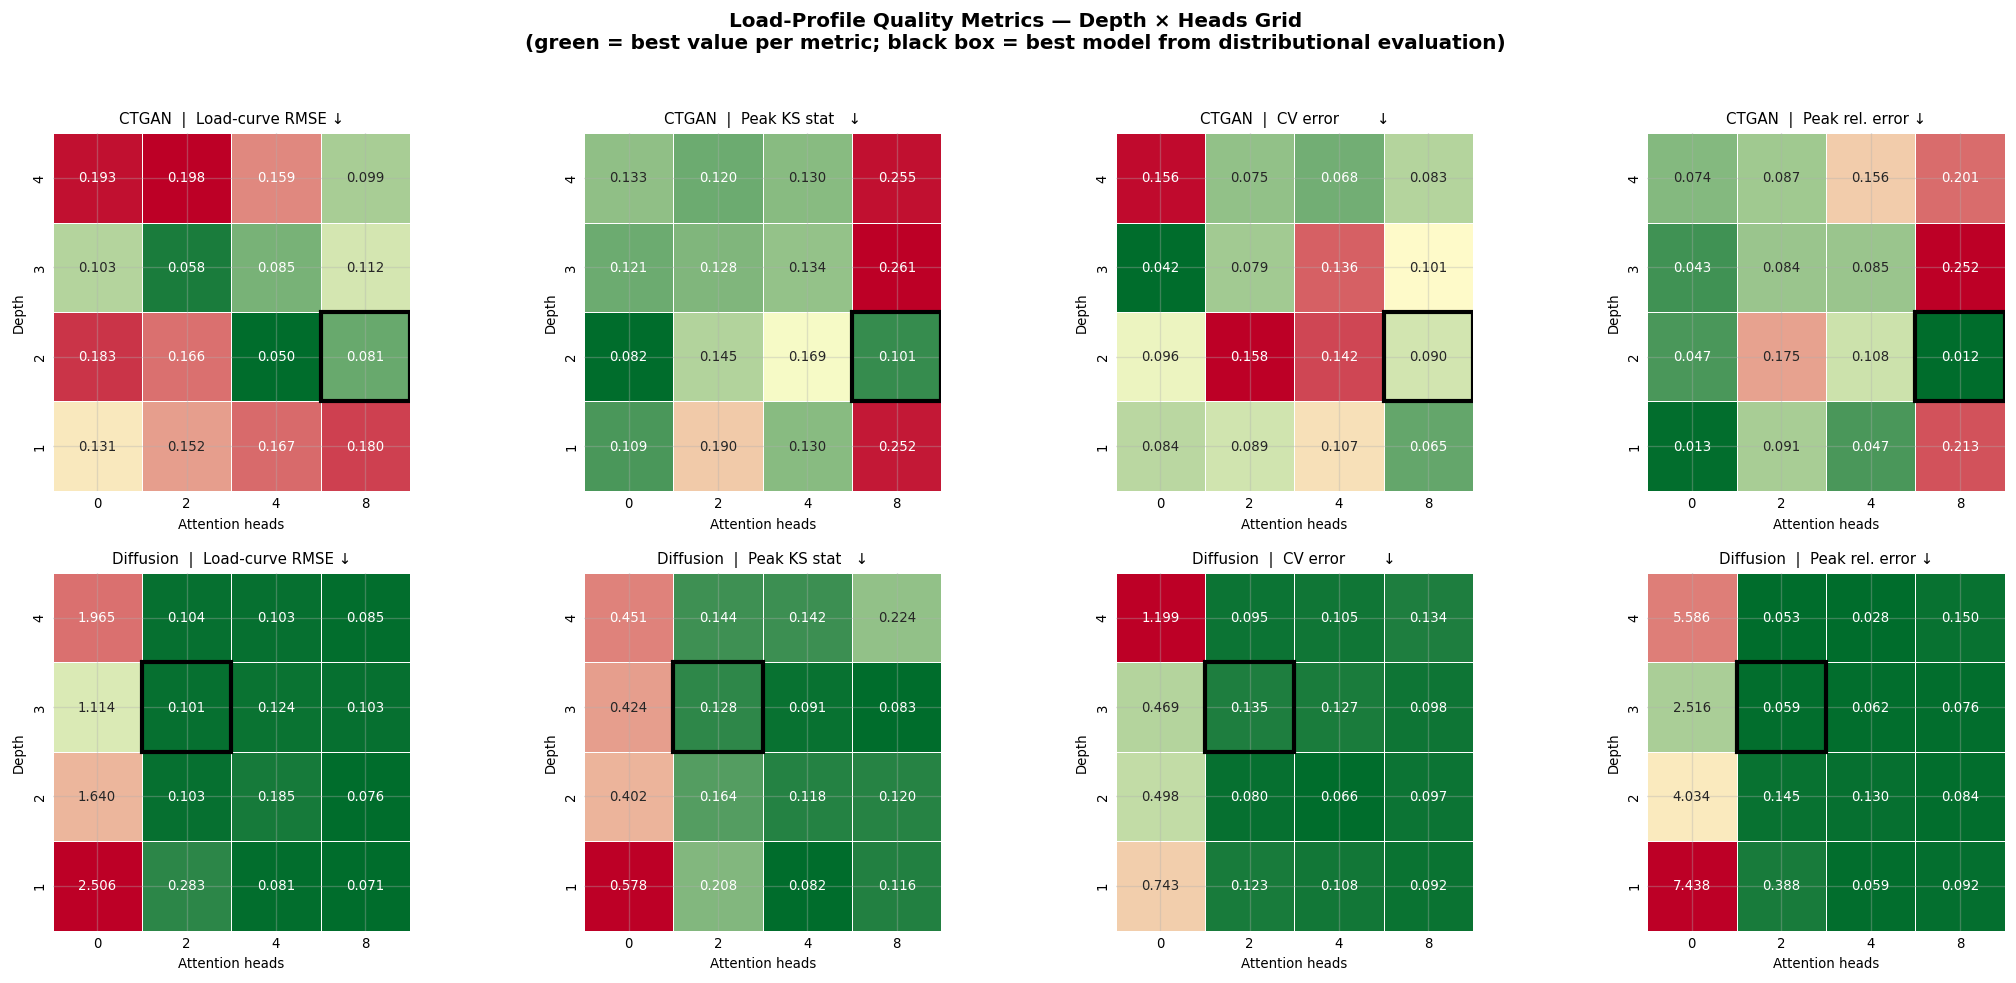

In [5]:
cmap_rg = LinearSegmentedColormap.from_list("rg", ["#006d2c", "#ffffcc", "#bd0026"], N=256)

metric_cfg = [
    ("rmse",         "Load-curve RMSE ↓"),
    ("ks_peak",      "Peak KS stat   ↓"),
    ("cv_err",       "CV error        ↓"),
    ("peak_rel_err", "Peak rel. error ↓"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, (metric, title) in enumerate(metric_cfg):
    for row, (label, mdf, best_mid) in enumerate([
            ("CTGAN",     ctgan_metrics, BEST_CTGAN),
            ("Diffusion", diff_metrics,  BEST_DIFFUSION)]):

        ax  = axes[row, col]
        piv = (mdf.reset_index()[["depth", "heads", metric]]
               .pivot_table(index="depth", columns="heads", values=metric)
               .sort_index(ascending=False))   # high depth at top

        vmin, vmax = piv.values.min(), piv.values.max()
        sns.heatmap(piv, annot=True, fmt=".3f", cmap=cmap_rg,
                    cbar=False, square=True, linewidths=0.6, linecolor="white",
                    annot_kws={"size": 8}, ax=ax, vmin=vmin, vmax=vmax)

        # Highlight known-best model with black border
        bm = re.match(r"d(\d+)_h(\d+)", best_mid)
        if bm:
            bd, bh = int(bm.group(1)), int(bm.group(2))
            if bd in piv.index.tolist() and bh in piv.columns.tolist():
                r = list(piv.index).index(bd)
                c = list(piv.columns).index(bh)
                ax.add_patch(plt.Rectangle((c, r), 1, 1, fill=False,
                                           edgecolor="black", lw=2.5, zorder=5))

        ax.set_title(f"{label}  |  {title}", fontsize=9)
        ax.set_xlabel("Attention heads", fontsize=8)
        ax.set_ylabel("Depth", fontsize=8)
        ax.tick_params(length=0, labelsize=8)

plt.suptitle(
    "Load-Profile Quality Metrics — Depth × Heads Grid\n"
    "(green = best value per metric; black box = best model from distributional evaluation)",
    fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("lp_metric_heatmaps.png", bbox_inches="tight")
plt.show()

## 4 · Daily Load Curves — All Model Configurations

All depth × heads configurations shown as thin grey lines; best model (from distributional evaluation) highlighted with ±1 SD band; real data as dashed blue line.

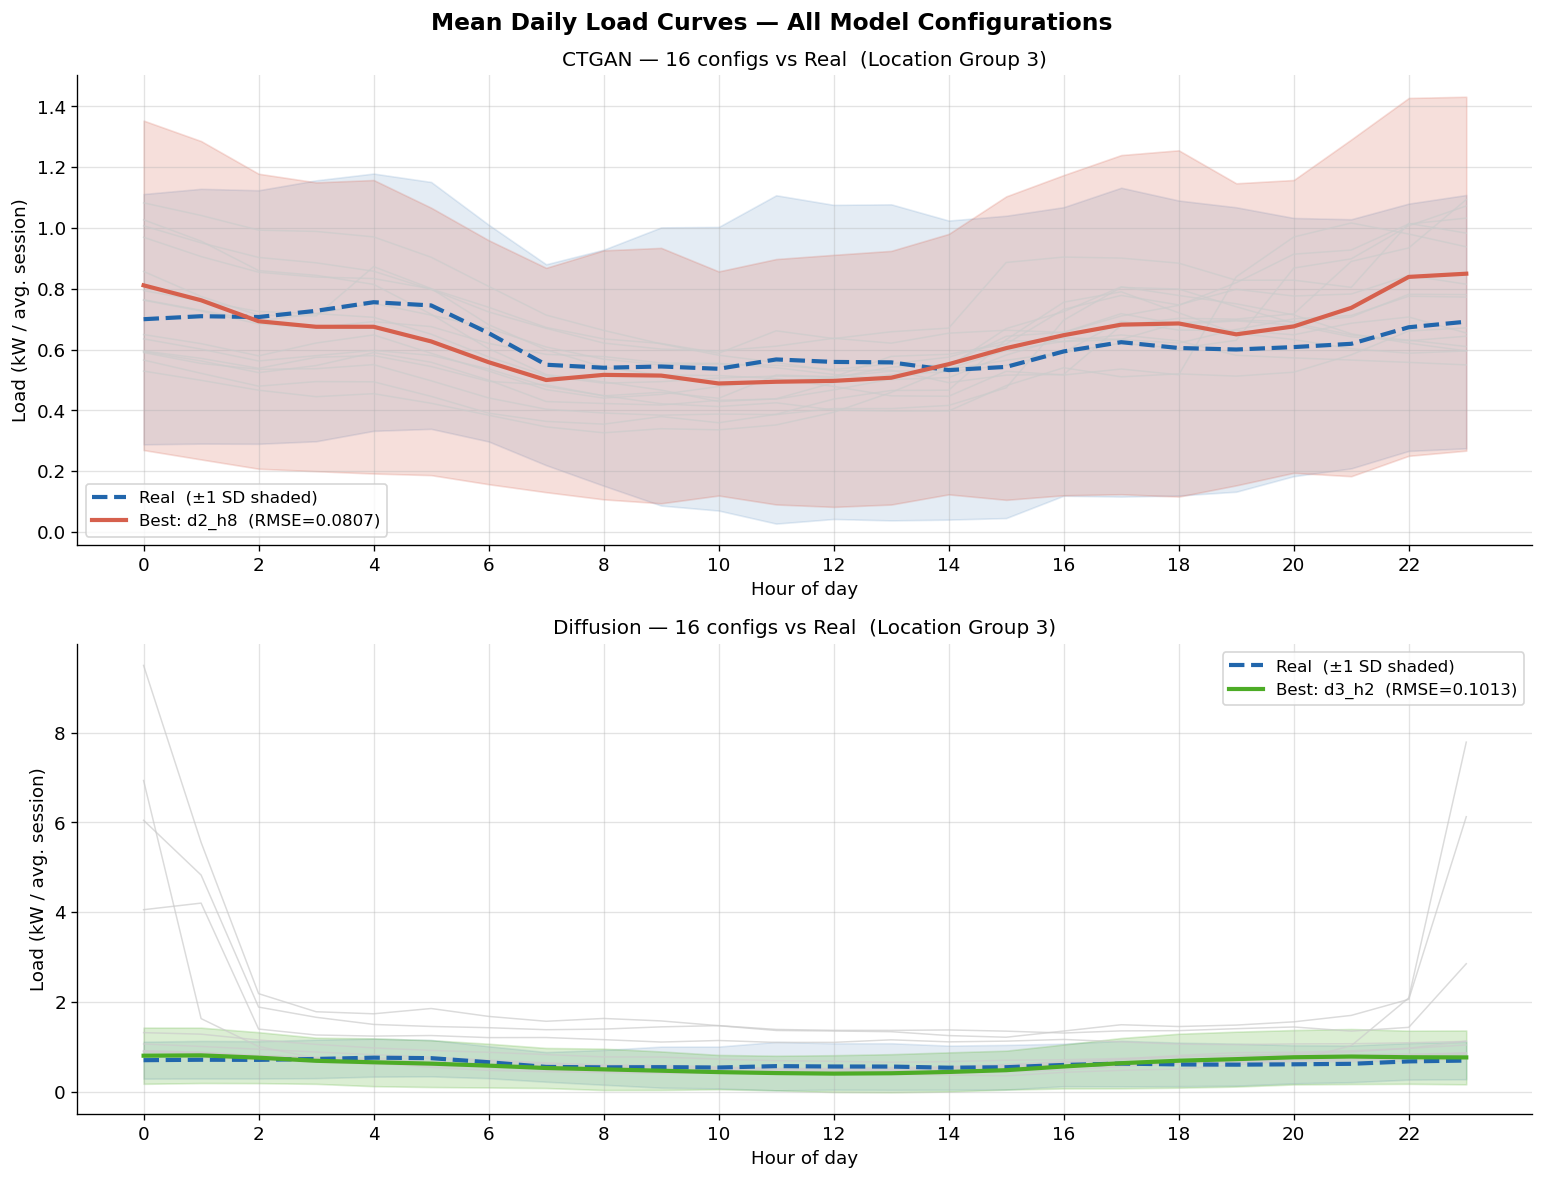

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharey=False)

for ax, (method, norms_dict, best_mid, c_best, mdf) in zip(axes, [
        ("CTGAN",     ctgan_norms, BEST_CTGAN,     C_CTGAN, ctgan_metrics),
        ("Diffusion", diff_norms,  BEST_DIFFUSION, C_DIFF,  diff_metrics)]):

    # Real ± 1 SD
    mu_r = norm_real.mean(axis=0).values
    sd_r = norm_real.std(axis=0).values
    ax.fill_between(hours, mu_r - sd_r, mu_r + sd_r, color=C_REAL, alpha=0.12)
    ax.plot(hours, mu_r, color=C_REAL, lw=2.5, ls="--",
            label="Real  (±1 SD shaded)", zorder=5)

    # All other configs — grey
    for mid, norm in norms_dict.items():
        if mid == best_mid:
            continue
        ax.plot(hours, norm.mean(axis=0).values,
                color=C_OTHER, lw=0.9, alpha=0.7, zorder=2)

    # Best config — highlighted with ±1 SD
    if best_mid in norms_dict:
        norm_b = norms_dict[best_mid]
        mu_b   = norm_b.mean(axis=0).values
        sd_b   = norm_b.std(axis=0).values
        rmse_b = mdf.loc[best_mid, "rmse"] if best_mid in mdf.index else float("nan")
        ax.fill_between(hours, mu_b - sd_b, mu_b + sd_b, color=c_best, alpha=0.2)
        ax.plot(hours, mu_b, color=c_best, lw=2.5,
                label=f"Best: {best_mid}  (RMSE={rmse_b:.4f})", zorder=5)

    ax.set_title(f"{method} — {len(norms_dict)} configs vs Real  "
                 f"(Location Group {LOCATION_GROUP})", fontsize=12)
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Load (kW / avg. session)")
    ax.set_xticks(range(0, 24, 2))
    ax.legend(fontsize=10)

plt.suptitle("Mean Daily Load Curves — All Model Configurations",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("lp_all_models_curves.png", bbox_inches="tight")
plt.show()

## 5 · Peak Demand

$P_{peak}^{(d)} = \max_h P_h^{(d)}$ per day.  Boxplot + KDE for Real vs best model per method.  KS test quantifies distributional similarity.

Summary statistics (kW / session):
  Real                        mean=1.220  median=1.167  p95=2.253  max=3.671
  CTGAN d2_h8                 mean=1.205  median=1.037  p95=2.575  max=3.635
  Diffusion d3_h2             mean=1.148  median=1.002  p95=2.634  max=4.203


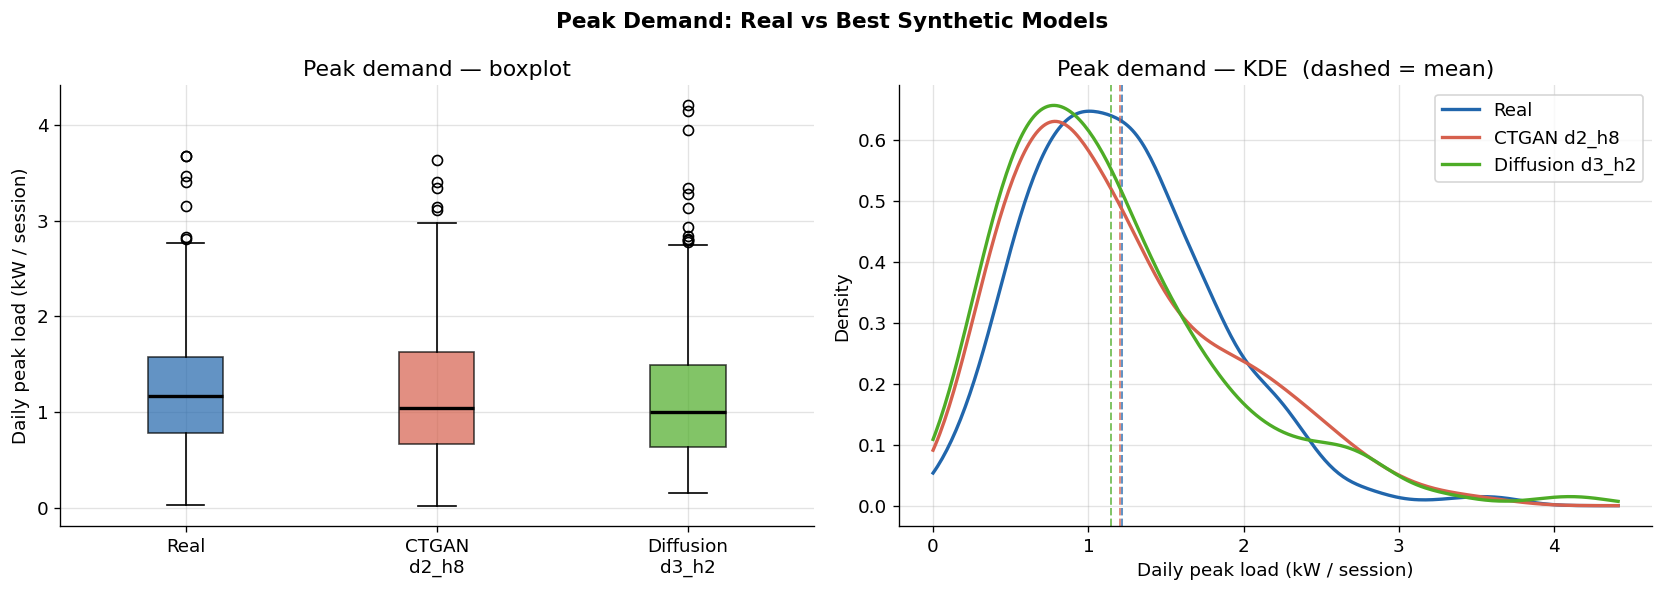


KS  Real vs CTGAN       : stat=0.1014  p=0.0239
KS  Real vs Diffusion   : stat=0.1277  p=0.0032


In [7]:
peak_ctgan_best = ctgan_norms[BEST_CTGAN].max(axis=1).values  if BEST_CTGAN     in ctgan_norms else None
peak_diff_best  = diff_norms[BEST_DIFFUSION].max(axis=1).values if BEST_DIFFUSION in diff_norms  else None

entries = [("Real", peak_real, C_REAL)]
if peak_ctgan_best is not None:
    entries.append((f"CTGAN\n{BEST_CTGAN}",     peak_ctgan_best, C_CTGAN))
if peak_diff_best is not None:
    entries.append((f"Diffusion\n{BEST_DIFFUSION}", peak_diff_best,  C_DIFF))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
bp = axes[0].boxplot([e[1] for e in entries], patch_artist=True,
                     medianprops=dict(color="black", lw=2))
for patch, e in zip(bp["boxes"], entries):
    patch.set_facecolor(e[2]); patch.set_alpha(0.7)
axes[0].set_xticks(range(1, len(entries) + 1))
axes[0].set_xticklabels([e[0] for e in entries])
axes[0].set_ylabel("Daily peak load (kW / session)")
axes[0].set_title("Peak demand — boxplot")

# Summary stats
print("Summary statistics (kW / session):")
for lbl, arr, _ in entries:
    print(f"  {lbl.replace(chr(10), ' '):26s}  "
          f"mean={arr.mean():.3f}  median={np.median(arr):.3f}  "
          f"p95={np.percentile(arr, 95):.3f}  max={arr.max():.3f}")

# KDE
xs = np.linspace(0, max(e[1].max() for e in entries) * 1.05, 300)
for lbl, arr, col in entries:
    kde = stats.gaussian_kde(arr)
    axes[1].plot(xs, kde(xs), color=col, lw=2, label=lbl.replace("\n", " "))
    axes[1].axvline(arr.mean(), color=col, lw=1.2, ls="--", alpha=0.7)
axes[1].set_xlabel("Daily peak load (kW / session)")
axes[1].set_ylabel("Density")
axes[1].set_title("Peak demand — KDE  (dashed = mean)")
axes[1].legend()

plt.suptitle("Peak Demand: Real vs Best Synthetic Models",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("lp_peak_demand.png", bbox_inches="tight")
plt.show()

# KS tests
print()
for method, peak_syn in [("CTGAN",     peak_ctgan_best),
                          ("Diffusion", peak_diff_best)]:
    if peak_syn is not None:
        ks, p = stats.ks_2samp(peak_real, peak_syn)
        print(f"KS  Real vs {method:12s}: stat={ks:.4f}  p={p:.4f}")

## 6 · Hourly Variability

$CV_h = \sigma_h / \mu_h$ per hour of day.  
Top row: all configs (grey) + best (colour) + real (dashed blue).  
Bottom row: $\Delta CV_h$ bars — positive means synthetic is *more* variable than real at that hour.

Top-3 divergent hours (CTGAN d2_h8 vs Real): h=6 (ΔCV=+0.174), h=5 (ΔCV=+0.157), h=4 (ΔCV=+0.155)
Top-3 divergent hours (Diffusion d3_h2 vs Real): h=6 (ΔCV=+0.298), h=5 (ΔCV=+0.292), h=4 (ΔCV=+0.255)


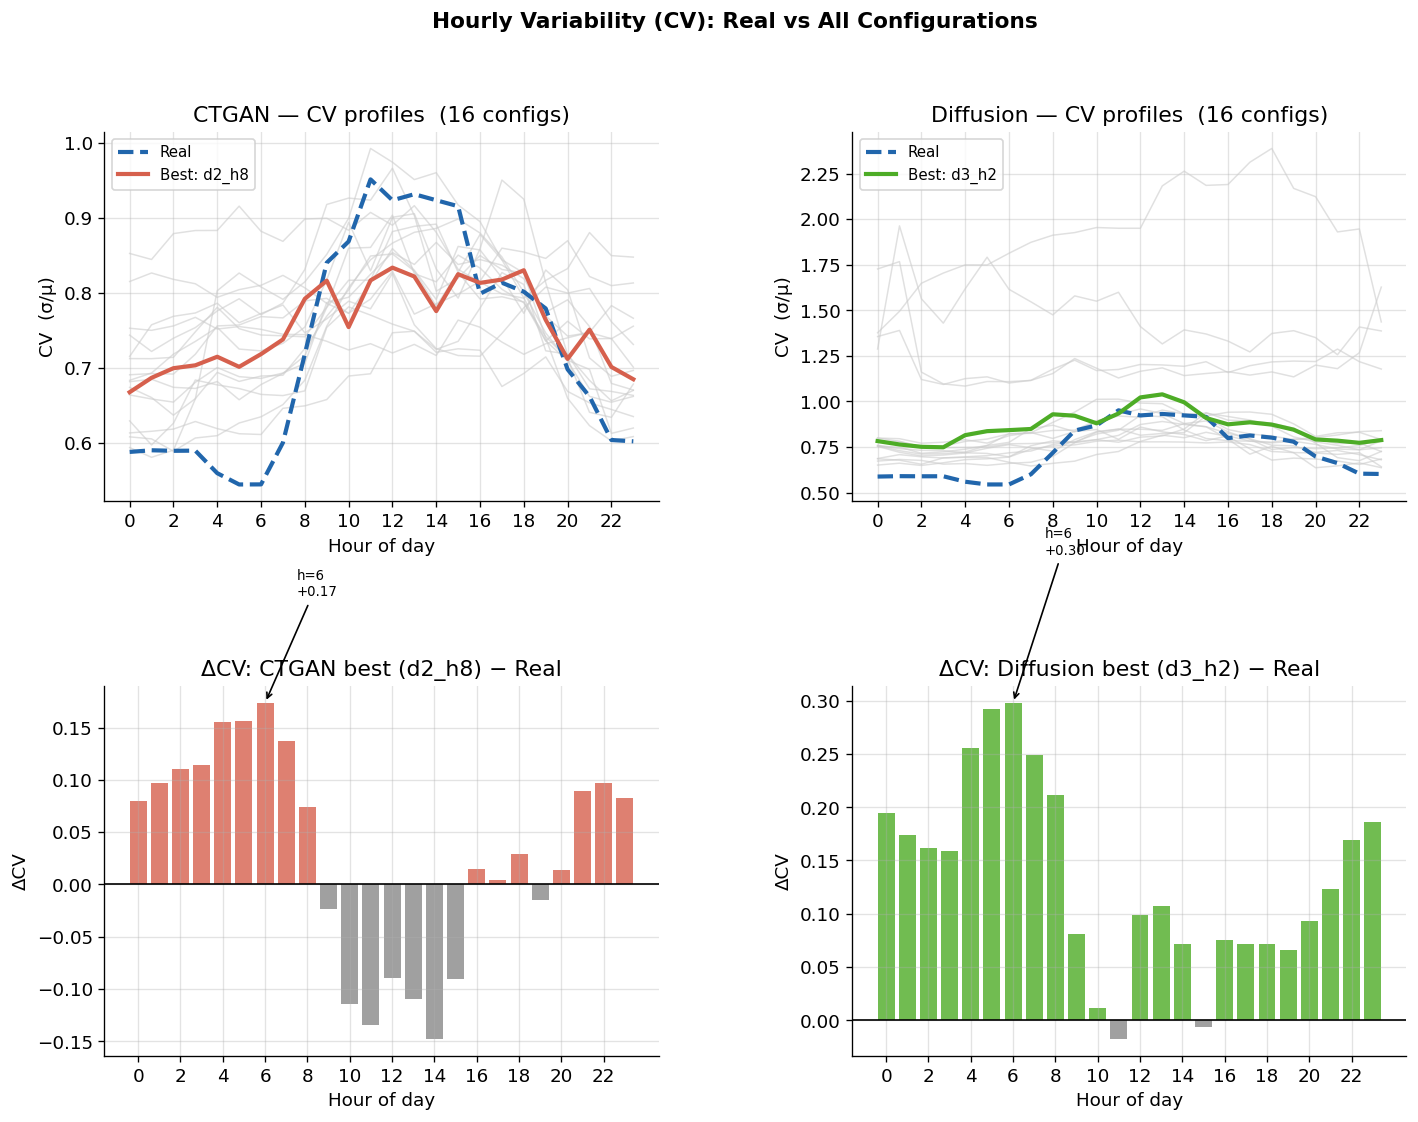

In [8]:
cv_ctgan_best = hourly_cv(ctgan_norms[BEST_CTGAN]) if BEST_CTGAN in ctgan_norms else None
cv_diff_best  = hourly_cv(diff_norms[BEST_DIFFUSION]) if BEST_DIFFUSION in diff_norms else None

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.35)

for col, (method, norms_dict, best_mid, c_best, cv_best) in enumerate([
        ("CTGAN",     ctgan_norms, BEST_CTGAN,     C_CTGAN, cv_ctgan_best),
        ("Diffusion", diff_norms,  BEST_DIFFUSION, C_DIFF,  cv_diff_best)]):

    # ── CV overlay ────────────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, col])
    for mid, norm in norms_dict.items():
        if mid == best_mid:
            continue
        ax.plot(hours, hourly_cv(norm), color=C_OTHER, lw=0.9, alpha=0.6)
    ax.plot(hours, cv_real, color=C_REAL, lw=2.5, ls="--", label="Real", zorder=4)
    if cv_best is not None:
        ax.plot(hours, cv_best, color=c_best, lw=2.5,
                label=f"Best: {best_mid}", zorder=5)
    ax.set_title(f"{method} — CV profiles  ({len(norms_dict)} configs)")
    ax.set_xlabel("Hour of day");  ax.set_ylabel("CV  (σ/μ)")
    ax.set_xticks(range(0, 24, 2));  ax.legend(fontsize=9)

    # ── ΔCV bars ──────────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, col])
    if cv_best is not None:
        delta  = cv_best - cv_real
        bar_colors = [c_best if d >= 0 else "#888888" for d in delta]
        ax2.bar(hours, delta, color=bar_colors, alpha=0.8, width=0.8)
        ax2.axhline(0, color="black", lw=1)

        worst_h  = int(np.argmax(np.abs(delta)))
        offset_x = worst_h + 1.5 if worst_h < 20 else worst_h - 5
        offset_y = delta[worst_h] * 1.3 + (0.05 if delta[worst_h] >= 0 else -0.05)
        ax2.annotate(f"h={worst_h}\n{delta[worst_h]:+.2f}",
                     xy=(worst_h, delta[worst_h]),
                     xytext=(offset_x, offset_y),
                     fontsize=8, arrowprops=dict(arrowstyle="->", lw=1))

        top3 = np.argsort(np.abs(delta))[::-1][:3]
        print(f"Top-3 divergent hours ({method} {best_mid} vs Real): "
              + ", ".join(f"h={h} (ΔCV={delta[h]:+.3f})" for h in top3))

    ax2.set_title(f"ΔCV: {method} best ({best_mid}) − Real")
    ax2.set_xlabel("Hour of day");  ax2.set_ylabel("ΔCV")
    ax2.set_xticks(range(0, 24, 2))

plt.suptitle("Hourly Variability (CV): Real vs All Configurations",
             fontsize=13, fontweight="bold")
plt.savefig("lp_variability.png", bbox_inches="tight")
plt.show()

## 7 · Summary Table — All Models

All metrics vs real data (Location Group 3). Colour gradient: red = worse, green = better.

In [9]:
rows = []
for method, mdf, best_mid, norms_dict in [
        ("CTGAN",     ctgan_metrics, BEST_CTGAN,     ctgan_norms),
        ("Diffusion", diff_metrics,  BEST_DIFFUSION, diff_norms)]:
    for mid in sorted(mdf.index):
        row   = mdf.loc[mid]
        norm  = norms_dict[mid]
        ks, p = stats.ks_2samp(peak_real, norm.max(axis=1).values)
        rows.append({
            "Method":        method,
            "Model":         mid,
            "Best ★":        "★" if mid == best_mid else "",
            "Depth":         int(row["depth"]),
            "Heads":         int(row["heads"]),
            "RMSE":          round(row["rmse"], 4),
            "KS stat":       round(ks, 4),
            "KS p-value":    round(p, 4),
            "CV error":      round(row["cv_err"], 4),
            "Peak rel.err %": round(row["peak_rel_err"] * 100, 1),
        })

summary = pd.DataFrame(rows)
display(
    summary.sort_values(["Method", "RMSE"])
           .style
           .background_gradient(subset=["RMSE", "KS stat", "CV error", "Peak rel.err %"],
                                 cmap="YlOrRd")
           .format({"RMSE": "{:.4f}", "KS stat": "{:.4f}",
                    "CV error": "{:.4f}", "Peak rel.err %": "{:.1f}%"})
           .set_caption(f"Load-profile metrics vs Real data  (Location Group {LOCATION_GROUP})")
)

,Method,Model,Best ★,Depth,Heads,RMSE,KS stat,KS p-value,CV error,Peak rel.err %
6,CTGAN,d2_h4,,2,4,0.0504,0.1687,0.000000,0.1418,10.8%
9,CTGAN,d3_h2,,3,2,0.0582,0.1277,0.001800,0.0786,8.4%
7,CTGAN,d2_h8,★,2,8,0.0807,0.1014,0.023900,0.0897,1.2%
10,CTGAN,d3_h4,,3,4,0.0853,0.1345,0.000900,0.1361,8.5%
15,CTGAN,d4_h8,,4,8,0.0990,0.2552,0.000000,0.0830,20.1%
8,CTGAN,d3_h0,,3,0,0.1025,0.1206,0.003900,0.0416,4.3%
11,CTGAN,d3_h8,,3,8,0.1120,0.2612,0.000000,0.1008,25.2%
0,CTGAN,d1_h0,,1,0,0.1311,0.1088,0.012400,0.0841,1.3%
1,CTGAN,d1_h2,,1,2,0.1523,0.1903,0.000000,0.0892,9.1%
14,CTGAN,d4_h4,,4,4,0.1586,0.1302,0.001400,0.0678,15.6%


## 8 · Association Structure — Frobenius Norm

The **Spearman rank-correlation matrix** is computed over the three key charging variables (`plugin_hour`, `connection_time`, `energy_session`) for the real dataset and for every synthetic model configuration.  
The **Frobenius norm** of the element-wise difference matrix aggregates dependency discrepancies across all variable pairs into a single scalar: $\|C^{real} - C^{syn}\|_F = \sqrt{\sum_{i,j}(c^{real}_{ij} - c^{syn}_{ij})^2}$.  Lower values indicate closer agreement in dependency structure.

Real — Spearman association matrix:
                 plugin_hour  connection_time  energy_session
plugin_hour            1.000            0.201           0.132
connection_time        0.201            1.000          -0.019
energy_session         0.132           -0.019           1.000


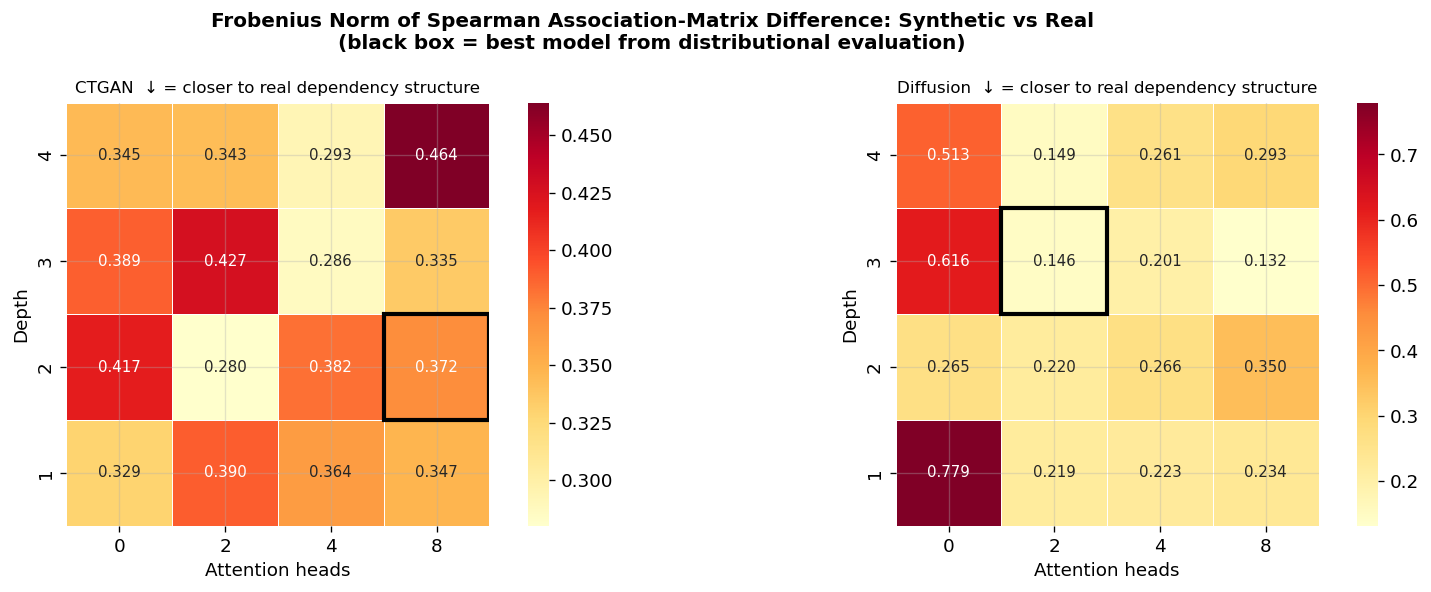

In [10]:
ASSOC_COLS = ["plugin_hour", "connection_time", "energy_session"]


def assoc_matrix(df):
    """Spearman rank-correlation matrix for the three key charging variables."""
    sub = df[ASSOC_COLS].dropna().astype(float)
    res = stats.spearmanr(sub)
    # scipy >= 1.7 uses .statistic; older uses .correlation
    corr = getattr(res, "statistic", None)
    if corr is None:
        corr = res.correlation
    return np.atleast_2d(np.array(corr, dtype=float))


def frob_norm(a, b):
    return float(np.linalg.norm(a - b, "fro"))


# ── Real association matrix ───────────────────────────────────────────────────
mat_real = assoc_matrix(real_raw)
print("Real — Spearman association matrix:")
print(pd.DataFrame(mat_real, index=ASSOC_COLS, columns=ASSOC_COLS).round(3).to_string())

# ── Per-model Frobenius norms ─────────────────────────────────────────────────
def frob_df(models_dict):
    rows = []
    for mid, df in models_dict.items():
        m = re.match(r"d(\d+)_h(\d+)", mid)
        rows.append({
            "model_id":  mid,
            "depth":     int(m.group(1)),
            "heads":     int(m.group(2)),
            "frobenius": frob_norm(mat_real, assoc_matrix(df)),
        })
    return pd.DataFrame(rows).set_index("model_id")


ctgan_frob = frob_df(ctgan_models)
diff_frob  = frob_df(diff_models)

# ── Depth × Heads heatmaps ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, mdf, best_mid) in zip(axes, [
        ("CTGAN",     ctgan_frob, BEST_CTGAN),
        ("Diffusion", diff_frob,  BEST_DIFFUSION)]):

    piv = (mdf.reset_index()[["depth", "heads", "frobenius"]]
           .pivot_table(index="depth", columns="heads", values="frobenius")
           .sort_index(ascending=False))

    sns.heatmap(piv, annot=True, fmt=".3f", cmap="YlOrRd",
                cbar=True, square=True, linewidths=0.6, linecolor="white",
                annot_kws={"size": 9}, ax=ax)

    bm = re.match(r"d(\d+)_h(\d+)", best_mid)
    if bm:
        bd, bh = int(bm.group(1)), int(bm.group(2))
        if bd in piv.index.tolist() and bh in piv.columns.tolist():
            ri = list(piv.index).index(bd)
            ci = list(piv.columns).index(bh)
            ax.add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False,
                                       edgecolor="black", lw=2.5, zorder=5))

    ax.set_title(f"{label}  ↓ = closer to real dependency structure", fontsize=10)
    ax.set_xlabel("Attention heads")
    ax.set_ylabel("Depth")

plt.suptitle(
    "Frobenius Norm of Spearman Association-Matrix Difference: Synthetic vs Real\n"
    "(black box = best model from distributional evaluation)",
    fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("lp_frobenius_heatmap.png", bbox_inches="tight")
plt.show()

Frobenius norm summary:
  Real vs CTGAN  d2_h8                  : 0.3715
  Real vs Diffusion  d3_h2              : 0.1462


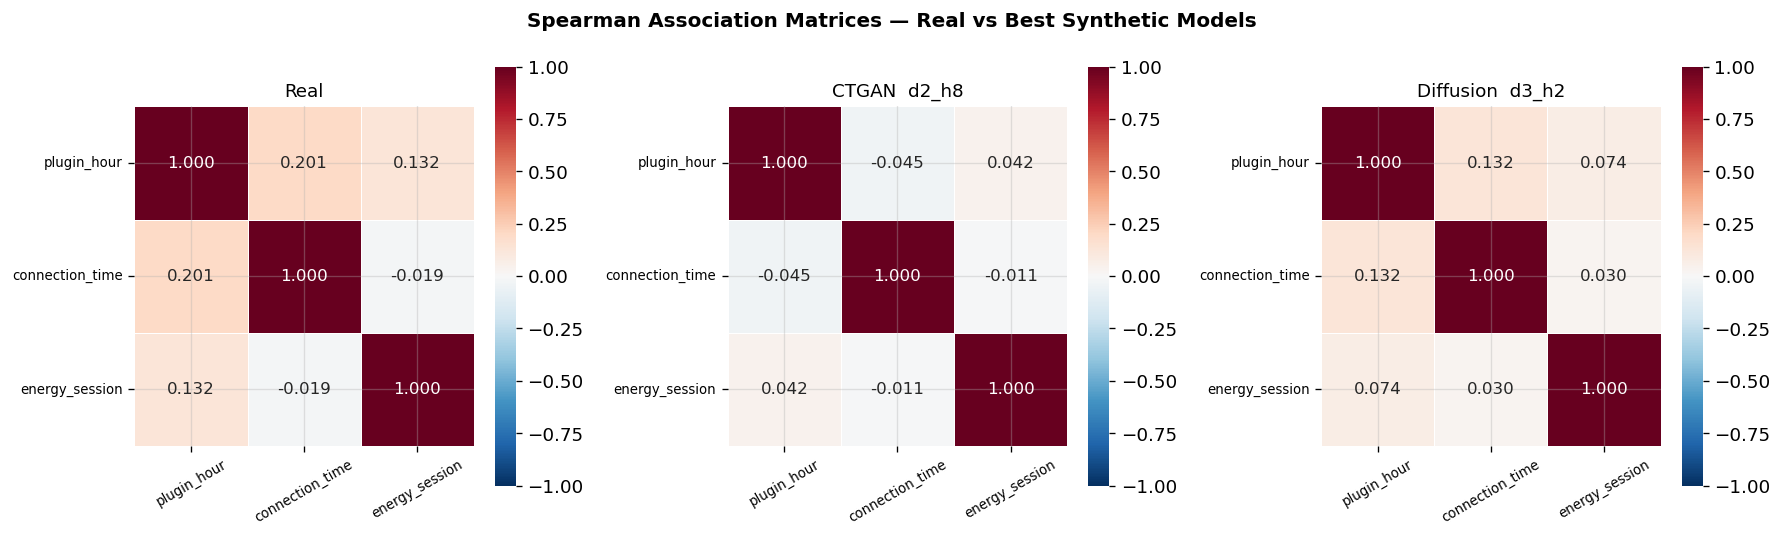

In [11]:
# ── Side-by-side matrices: Real vs best CTGAN vs best Diffusion ───────────────
datasets_assoc = [
    ("Real",                            real_raw),
    (f"CTGAN  {BEST_CTGAN}",            ctgan_models[BEST_CTGAN]),
    (f"Diffusion  {BEST_DIFFUSION}",    diff_models[BEST_DIFFUSION]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
mats = []

for ax, (label, df) in zip(axes, datasets_assoc):
    mat = assoc_matrix(df)
    mats.append(mat)
    sns.heatmap(
        pd.DataFrame(mat, index=ASSOC_COLS, columns=ASSOC_COLS),
        annot=True, fmt=".3f", cmap="RdBu_r",
        center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.6, cbar=True, ax=ax,
        annot_kws={"size": 10},
    )
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

print("Frobenius norm summary:")
for (label, _), mat in zip(datasets_assoc[1:], mats[1:]):
    print(f"  Real vs {label:30s}: {frob_norm(mats[0], mat):.4f}")

plt.suptitle("Spearman Association Matrices — Real vs Best Synthetic Models",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("lp_association_matrices.png", bbox_inches="tight")
plt.show()

## 9 · Pairwise 2-D Distributions — Key Charging Variables

Visual inspection of joint distributions for the three variable pairs that govern charging overlap and aggregate demand:

| Pair | Why it matters |
|---|---|
| Plug-in hour × Connection time | Determines how sessions overlap on the timeline |
| Plug-in hour × Energy (kWh) | Captures time-of-day demand intensity |
| Connection time × Energy (kWh) | Governs average charging power $P = E / t_{conn}$ |

Spearman $\rho$ is annotated on each panel. Hexbin density — darker = more sessions.

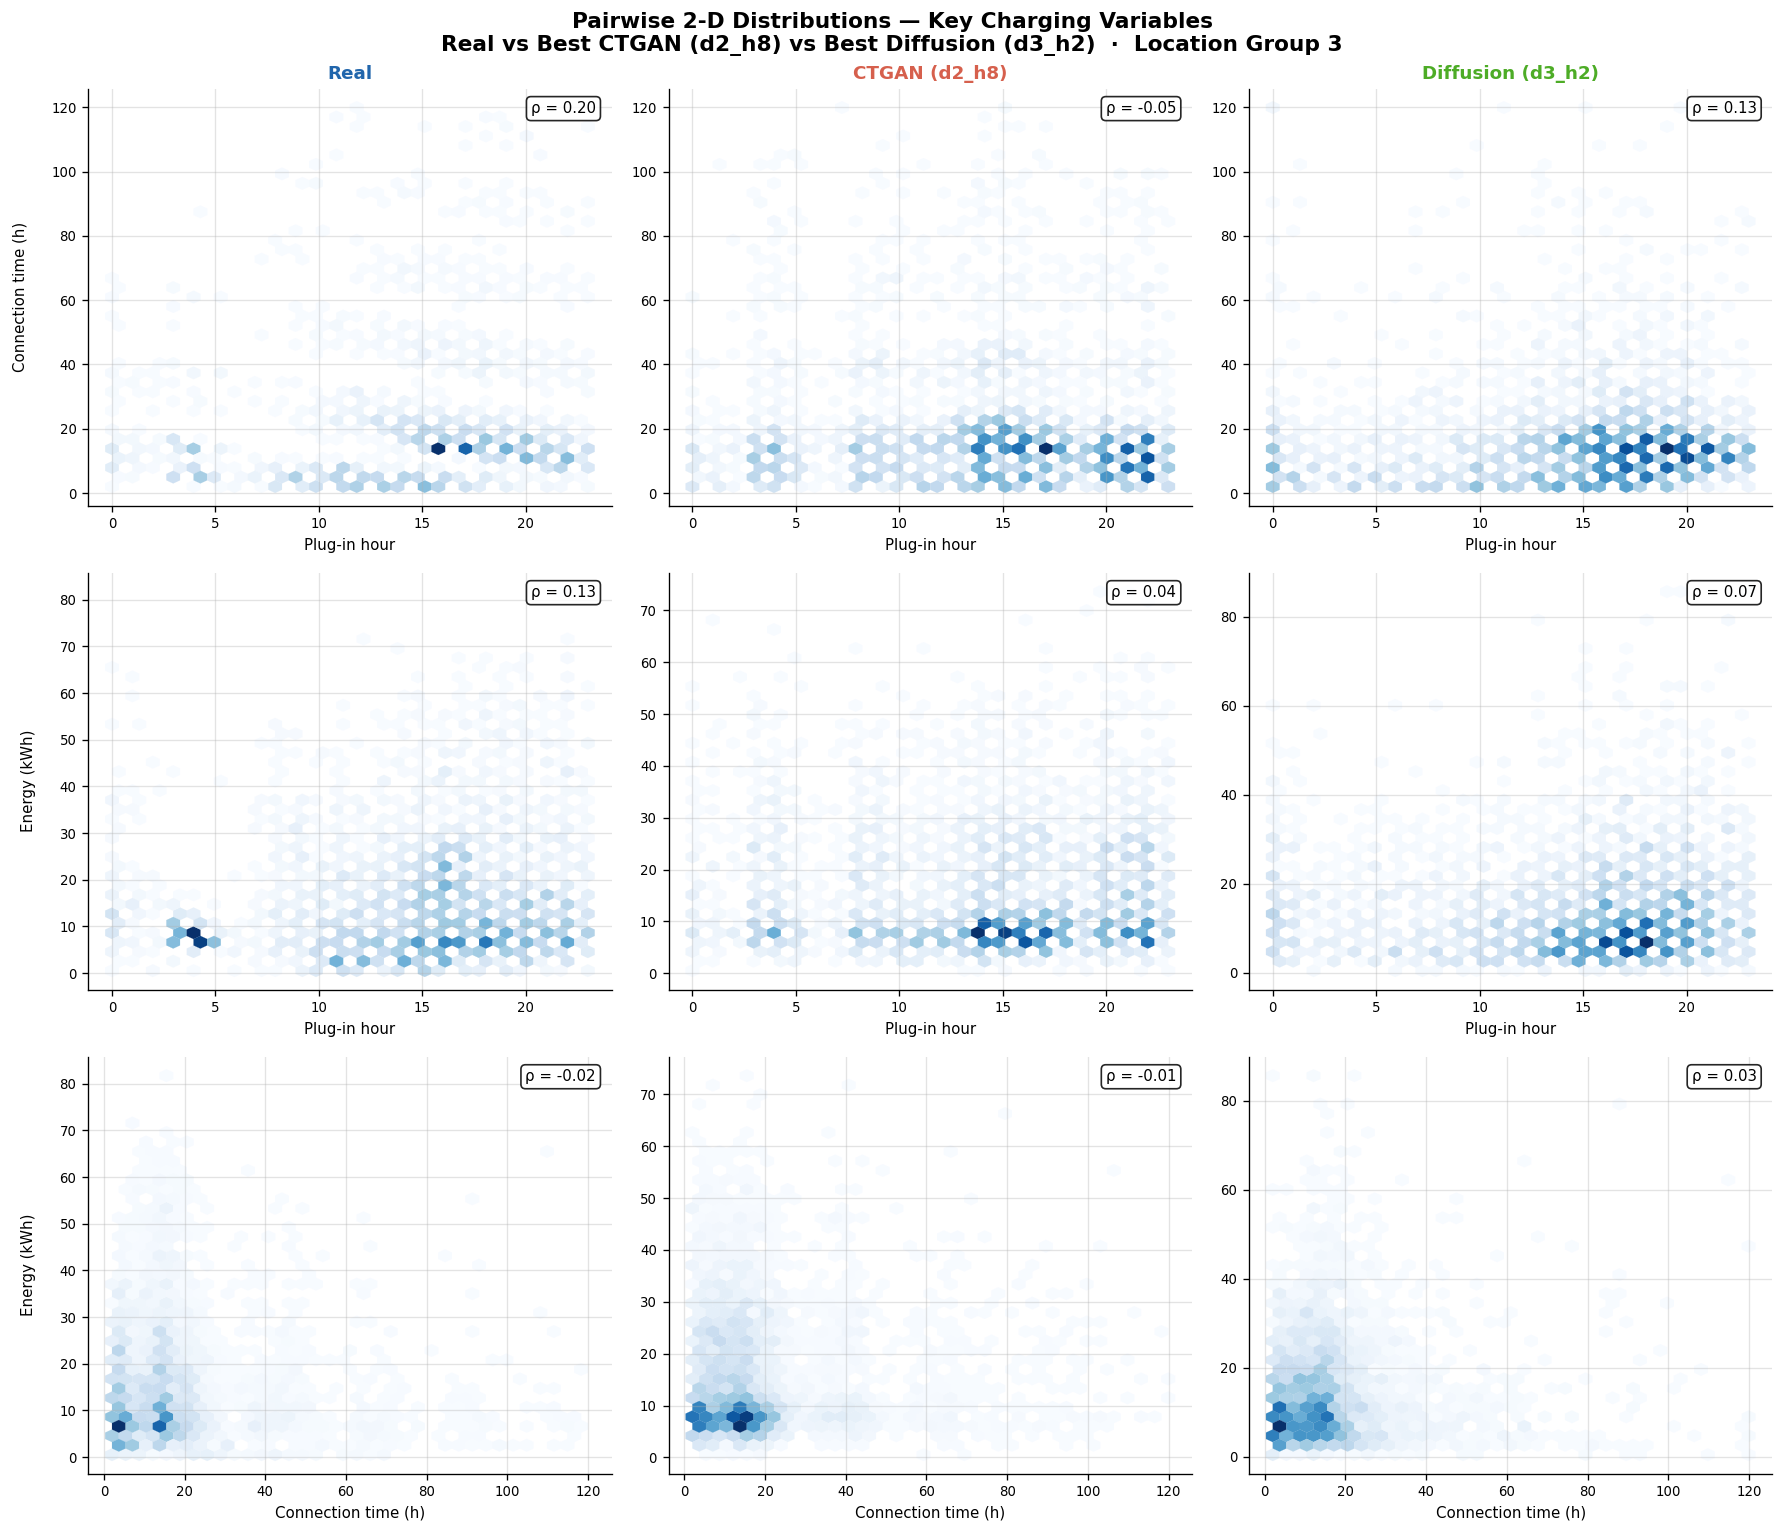

In [12]:
PAIRS = [
    ("plugin_hour",     "connection_time",  "Plug-in hour",        "Connection time (h)"),
    ("plugin_hour",     "energy_session",   "Plug-in hour",        "Energy (kWh)"),
    ("connection_time", "energy_session",   "Connection time (h)", "Energy (kWh)"),
]

datasets_2d = [
    ("Real",                             real_raw,                      C_REAL),
    (f"CTGAN ({BEST_CTGAN})",            ctgan_models[BEST_CTGAN],      C_CTGAN),
    (f"Diffusion ({BEST_DIFFUSION})",    diff_models[BEST_DIFFUSION],   C_DIFF),
]

fig, axes = plt.subplots(len(PAIRS), len(datasets_2d), figsize=(15, 13))

for row, (xcol, ycol, xlabel, ylabel) in enumerate(PAIRS):
    for col, (label, df, color) in enumerate(datasets_2d):
        ax = axes[row, col]

        sub = (df[[xcol, ycol]]
               .dropna()
               .astype(float)
               .sample(min(5000, len(df)), random_state=42))

        hb = ax.hexbin(sub[xcol], sub[ycol],
                       gridsize=35, cmap="Blues", mincnt=1, linewidths=0.1)

        # Spearman ρ
        rho, _ = stats.spearmanr(sub[xcol], sub[ycol])
        ax.text(0.97, 0.97, f"ρ = {rho:.2f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))

        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(ylabel if col == 0 else "", fontsize=9)
        ax.tick_params(labelsize=8)

        if row == 0:
            ax.set_title(label, fontsize=11, fontweight="bold", color=color)

        # Left-hand pair label
        if col == 0:
            ax.set_ylabel(f"{ylabel}\n", fontsize=9)

plt.suptitle(
    "Pairwise 2-D Distributions — Key Charging Variables\n"
    f"Real vs Best CTGAN ({BEST_CTGAN}) vs Best Diffusion ({BEST_DIFFUSION})  ·  "
    f"Location Group {LOCATION_GROUP}",
    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("lp_pairwise_2d.png", bbox_inches="tight")
plt.show()